In [ ]:
"""
HH Goa 2026 — Build unified corpus + load into Qdrant + SQLite
=================================================================
Run each "# %% CELL N" block as a separate Jupyter cell, in order.

Design:
  - Qdrant  -> English-only (text_en) + metadata, for vector search + filtering
  - SQLite  -> native-language text (Hindi/Odia/Telugu) + query/answer, for lookup after retrieval
  - 3 chunking strategies (passage_native, fixed_overlap, semantic) kept -- required by task
  - Dedup near-identical chunks (across strategies) BEFORE storing -- solves storage bloat
  - Payload indexes created BEFORE upsert -- solves filtered-search latency
"""

In [ ]:
# %% CELL 1 — Install (run once)
# !pip install "huggingface_hub[hf_xet]" pyarrow pandas sentence-transformers qdrant-client spacy scikit-learn
# !python -m spacy download en_core_web_sm

In [1]:
# %% CELL 2 — Imports + Config
import re
import uuid
import sqlite3
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from difflib import SequenceMatcher
from huggingface_hub import hf_hub_download

In [2]:
SAMPLE_SIZE_PER_LANG = 3000  # <-- your current target
QUERY_TYPE_DIST = {
    "DESCRIPTION": 0.529,
    "NUMERIC": 0.263,
    "ENTITY": 0.089,
    "LOCATION": 0.063,
    "PERSON": 0.056,
}
YEAR_RE = re.compile(r"\b(1[89]\d{2}|20\d{2})\b")

UNIFIED_FILE = "../unified_corpus.parquet"  # full archive, includes native text
SQLITE_DB = "native_text_lookup.db"                 # native text lookup
QDRANT_COLLECTION = "msmarco_english_corpus"        # English-only vectors + metadata
EMBED_MODEL = "BAAI/bge-small-en-v1.5"
EMBED_DIM = 384
DEDUP_THRESHOLD = 0.9  # SequenceMatcher ratio above which chunks are considered near-duplicate
DATA_DIR = "../MSMARCO-XI/train/hintrain.parquet"

print("Config loaded.")

Config loaded.


In [3]:
def download_language_file(repo_id: str, filename: str) -> str:
    # NEVER use snapshot_download() -- pulls the entire ~55GB repo
    return hf_hub_download(repo_id=repo_id, filename=filename, repo_type="dataset")

print("Download helpers ready.")

Download helpers ready.


In [4]:
# %% CELL 3 — Download + stream-read helpers (avoid OOM / snapshot_download)
def stream_read_parquet(path: str, batch_size: int = 5000) -> pd.DataFrame:
    """Read a large parquet file in batches to avoid ArrowMemoryError."""
    pf = pq.ParquetFile(path)
    batches = [batch.to_pandas() for batch in pf.iter_batches(batch_size=batch_size)]
    return pd.concat(batches, ignore_index=True)


In [5]:
# %% CELL 4 — Stratified subsample by query_type
def stratified_sample(df: pd.DataFrame, n_total: int, seed: int = 42) -> pd.DataFrame:
    parts = []
    for qtype, frac in QUERY_TYPE_DIST.items():
        n = int(round(n_total * frac))
        pool = df[df["query_type"] == qtype]
        if len(pool) == 0:
            continue
        n = min(n, len(pool))
        parts.append(pool.sample(n=n, random_state=seed))
    return pd.concat(parts, ignore_index=True) if parts else df.sample(
        n=min(n_total, len(df)), random_state=seed
    )

print("Sampling helper ready.")

Sampling helper ready.


In [6]:
# %% CELL 5 — Explode passages -> normalize (KEEPS native text -- goes to SQLite later)
def explode_msmarco_xi(df: pd.DataFrame, lang_code: str) -> pd.DataFrame:
    """MSMARCO-XI: nested `passages` dict with parallel arrays.
    Native text (`text`, `query`, `answer`) is kept -- routed to SQLITE_FIELDS downstream,
    NOT written to Qdrant payload. query_en/answer_en kept for eval only.
    """
    rows = []
    for _, r in df.iterrows():
        p = r["passages"]
        eng_passages = p["English_passages"]
        trans_passages = p["Translated_passages"]
        is_sel = p["is_selected"]
        for i, (en_p, tr_p, sel) in enumerate(zip(eng_passages, trans_passages, is_sel)):
            rows.append({
                # Qdrant-bound
                "text_en": en_p,
                "passage_id": f"{lang_code}_{r['query_id']}_{i}",
                "query_id": int(r["query_id"]),
                "lang": lang_code,
                "query_type": r["query_type"],
                "source_dataset": "MSMARCO-XI",
                "is_selected": bool(sel),
                # SQLite-bound (native)
                "text": tr_p,
                "query": r["query"],
                "answer": r["Answer"],
                # Eval-only
                "query_en": r["Eng_Query"],
                "answer_en": r["Eng_Answer"],
            })
    return pd.DataFrame(rows)

In [7]:
def explode_indic_msmarco_telugu(df: pd.DataFrame) -> pd.DataFrame:
    """IndicMSMARCO (Telugu): flat structure, confirmed NO English field.
    text_en left as None -- Telugu is excluded from Qdrant embedding,
    but still fetchable via SQLite by query_id (cross-lingual lookup)."""
    rows = []
    for i, r in df.iterrows():
        rows.append({
            "text_en": None,
            "passage_id": f"te_{r['query_id']}_{i}",
            "query_id": int(r["query_id"]),
            "lang": "te",
            "query_type": r["query_type"],
            "source_dataset": "IndicMSMARCO",
            "is_selected": bool(r["is_selected"]),
            "text": r["passage"],
            "query": r["query"],
            "answer": r["answer"],
            "query_en": None,
            "answer_en": None,
        })
    return pd.DataFrame(rows)

print("Explode/normalize functions ready.")

Explode/normalize functions ready.


In [8]:
# %% CELL 6 — Enrich: regex years + spaCy NER (on text_en only)
def enrich(df: pd.DataFrame) -> pd.DataFrame:
    import spacy
    nlp = spacy.load("en_core_web_sm")

    year_mentions, ppl, orgs, locs = [], [], [], []
    for doc_text in nlp.pipe(df["text_en"].fillna("").tolist(), batch_size=256):
        year_mentions.append([int(y) for y in YEAR_RE.findall(doc_text.text)])
        ppl.append([e.text for e in doc_text.ents if e.label_ == "PERSON"])
        orgs.append([e.text for e in doc_text.ents if e.label_ == "ORG"])
        locs.append([e.text for e in doc_text.ents if e.label_ in ("GPE", "LOC")])

    df["year_mentions"] = year_mentions
    df["entities_people"] = ppl
    df["entities_orgs"] = orgs
    df["entities_locations"] = locs
    return df

print("Enrich function ready.")

Enrich function ready.


In [9]:
# %% CELL 7 — Chunking: 3 strategies (all kept -- required by task)
def chunk_passage_native(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["chunk_strategy"] = "passage_native"
    out["chunk_id"] = out["passage_id"] + "_native"
    return out

In [10]:
def chunk_fixed_overlap(df: pd.DataFrame, chunk_tokens: int = 256, overlap: float = 0.2) -> pd.DataFrame:
    rows = []
    step = int(chunk_tokens * (1 - overlap))
    for _, r in df.iterrows():
        words = (r["text_en"] or "").split()
        if len(words) <= chunk_tokens:
            spans = [words]
        else:
            spans = [words[i:i + chunk_tokens] for i in range(0, len(words), step) if words[i:i + chunk_tokens]]
        for j, span in enumerate(spans):
            new_row = r.to_dict()
            new_row["text_en"] = " ".join(span)
            new_row["chunk_strategy"] = "fixed_overlap"
            new_row["chunk_id"] = f"{r['passage_id']}_fixed_{j}"
            rows.append(new_row)
    return pd.DataFrame(rows)

In [11]:
def chunk_semantic(df: pd.DataFrame, model, similarity_threshold: float = 0.75) -> pd.DataFrame:
    import re as _re
    rows = []
    for _, r in df.iterrows():
        sents = [s.strip() for s in _re.split(r"(?<=[.!?])\s+", r["text_en"] or "") if s.strip()]
        if len(sents) <= 1:
            groups = [sents]
        else:
            embs = model.encode(sents, normalize_embeddings=True)
            groups, current = [], [sents[0]]
            for i in range(1, len(sents)):
                sim = float(np.dot(embs[i - 1], embs[i]))
                if sim < similarity_threshold:
                    groups.append(current)
                    current = []
                current.append(sents[i])
            groups.append(current)
        for j, g in enumerate(groups):
            new_row = r.to_dict()
            new_row["text_en"] = " ".join(g)
            new_row["chunk_strategy"] = "semantic"
            new_row["chunk_id"] = f"{r['passage_id']}_sem_{j}"
            rows.append(new_row)
    return pd.DataFrame(rows)

In [12]:
def tag_metadata_aware(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["has_year"] = df["year_mentions"].apply(lambda y: len(y) > 0)
    df["has_person"] = df["entities_people"].apply(lambda p: len(p) > 0)
    df["has_org"] = df["entities_orgs"].apply(lambda o: len(o) > 0)
    df["has_location"] = df["entities_locations"].apply(lambda l: len(l) > 0)
    return df

print("Chunking functions ready.")

Chunking functions ready.


In [13]:
# %% CELL 8 — Dedup near-identical chunks (fixes storage bloat from strategy convergence)
def dedupe_chunks(df: pd.DataFrame, threshold: float = DEDUP_THRESHOLD) -> pd.DataFrame:
    """Within each source passage_id, drop near-duplicate chunks across strategies."""
    keep_rows = []
    before = len(df)
    for passage_id, group in df.groupby("passage_id"):
        seen_texts = []
        for _, row in group.iterrows():
            text = row["text_en"] or ""
            if any(SequenceMatcher(None, text, s).ratio() > threshold for s in seen_texts):
                continue
            seen_texts.append(text)
            keep_rows.append(row)
    result = pd.DataFrame(keep_rows)
    after = len(result)
    print(f"Dedup: {before:,} -> {after:,} chunks ({before - after:,} removed, "
          f"{(before - after) / before * 100:.1f}% reduction)")
    return result

print("Dedup function ready.")

Dedup function ready.


In [14]:
# %% CELL 9 — Build SQLite native-text lookup
def build_native_lookup(df: pd.DataFrame, db_path: str = SQLITE_DB):
    native_lookup = df.drop_duplicates(subset=["passage_id"])[
        ["passage_id", "query_id", "lang", "text", "query", "answer"]
    ]
    conn = sqlite3.connect(db_path)
    native_lookup.to_sql("passages", conn, if_exists="replace", index=False)
    conn.execute("CREATE INDEX IF NOT EXISTS idx_passage_id ON passages(passage_id)")
    conn.execute("CREATE INDEX IF NOT EXISTS idx_query_id ON passages(query_id)")
    conn.commit()
    conn.close()
    print(f"SQLite native lookup: {len(native_lookup):,} unique passages -> {db_path}")

print("SQLite builder ready.")

SQLite builder ready.


In [15]:
# %% CELL 10 — Write full archive (parquet, includes everything -- source of truth)
def write_unified_file(df: pd.DataFrame, path: str = UNIFIED_FILE):
    df.to_parquet(path, index=False)
    print(f"Archive written: {len(df):,} rows -> {path}")

print("Archive writer ready.")

Archive writer ready.


In [27]:
# %% CELL 11 — Embed (English-only) + create collection WITH payload indexes FIRST + upsert
QDRANT_PAYLOAD_FIELDS = [
    "text_en", "passage_id", "query_id", "lang", "query_type", "source_dataset",
    "chunk_strategy", "chunk_id", "has_year", "has_person", "has_org", "has_location",
    "year_mentions",
]

def embed_and_upsert(df: pd.DataFrame, qdrant_url: str = "http://localhost:6333"):
    from sentence_transformers import SentenceTransformer
    from qdrant_client import QdrantClient
    from qdrant_client.models import Distance, VectorParams, PointStruct, PayloadSchemaType

    # Drop rows with no English text (Telugu) -- cannot be embedded, still in SQLite for lookup
    df = df[df["text_en"].notna() & (df["text_en"].str.strip() != "")].reset_index(drop=True)

    model = SentenceTransformer(
        "BAAI/bge-small-en-v1.5",
        local_files_only=True
    )

    print("Model loaded successfully!")
    client = QdrantClient(url=qdrant_url)

    # Clean slate
    if client.collection_exists(QDRANT_COLLECTION):
        client.delete_collection(collection_name=QDRANT_COLLECTION)

    client.create_collection(
        collection_name=QDRANT_COLLECTION,
        vectors_config=VectorParams(size=EMBED_DIM, distance=Distance.COSINE),
    )

    # --- Payload indexes created BEFORE upsert, as requested ---
    index_fields = [
        ("lang", PayloadSchemaType.KEYWORD),
        ("query_type", PayloadSchemaType.KEYWORD),
        ("chunk_strategy", PayloadSchemaType.KEYWORD),
        ("source_dataset", PayloadSchemaType.KEYWORD),
        ("has_year", PayloadSchemaType.BOOL),
        ("has_person", PayloadSchemaType.BOOL),
        ("has_org", PayloadSchemaType.BOOL),
        ("has_location", PayloadSchemaType.BOOL),
        ("year_mentions", PayloadSchemaType.INTEGER),
    ]
    for field, schema in index_fields:
        client.create_payload_index(collection_name=QDRANT_COLLECTION, field_name=field, field_schema=schema)
    print(f"Created {len(index_fields)} payload indexes before upsert.")

    texts = df["text_en"].tolist()
    vectors = model.encode(texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True)

    points = []
    for vec, (_, row) in zip(vectors, df.iterrows()):
        payload = {k: row[k] for k in QDRANT_PAYLOAD_FIELDS if k in row}
        points.append(PointStruct(id=str(uuid.uuid4()), vector=vec.tolist(), payload=payload))

    B = 256
    for i in range(0, len(points), B):
        client.upsert(collection_name=QDRANT_COLLECTION, points=points[i:i + B])

    print(f"Upserted {len(points):,} English-only points into '{QDRANT_COLLECTION}'")
    return client

print("Embed/upsert function ready.")


Embed/upsert function ready.


In [17]:
# %% CELL 12 — RUN: download + sample + normalize (Hindi shown; repeat pattern for Odia)
hi_path = DATA_DIR
hi_df = stream_read_parquet(hi_path)
hi_df = stratified_sample(hi_df, SAMPLE_SIZE_PER_LANG)
hi_norm = explode_msmarco_xi(hi_df, "hi")
print(f"Hindi normalized: {len(hi_norm):,} passage rows")

Hindi normalized: 29,905 passage rows


In [ ]:
# %% CELL 13 — (Optional) Odia -- uncomment when ready
# or_path = download_language_file("ai4bharat/MSMARCO-XI", "train/oritrain.parquet")
# or_df = stream_read_parquet(or_path)
# or_df = stratified_sample(or_df, SAMPLE_SIZE_PER_LANG)
# or_norm = explode_msmarco_xi(or_df, "or")
# print(f"Odia normalized: {len(or_norm):,} passage rows")

# %% CELL 14 — (Optional) Telugu -- uncomment when ready
# from datasets import load_dataset
# te_ds = load_dataset("ai4bharat/IndicMSMARCO", "te")
# te_df = te_ds["train"].to_pandas()
# te_norm = explode_indic_msmarco_telugu(te_df)
# print(f"Telugu normalized: {len(te_norm):,} passage rows")

In [18]:
# %% CELL 15 — Combine languages (add or_norm, te_norm here once uncommented above)
unified = pd.concat([hi_norm], ignore_index=True)  # + or_norm, te_norm when ready
print(f"Unified (pre-enrich): {len(unified):,} rows")

Unified (pre-enrich): 29,905 rows


In [19]:
# %% CELL 16 — Enrich (years + entities)
unified = enrich(unified)
print("Enrichment done.")
unified[["passage_id", "year_mentions", "entities_people", "entities_orgs"]].head()

Enrichment done.


,passage_id,year_mentions,entities_people,entities_orgs
0,hi_673702_0,[],[],[]
1,hi_673702_1,[],[],[]
2,hi_673702_2,[],[],[]
3,hi_673702_3,[],[],[]
4,hi_673702_4,[],[],[]


In [20]:
# %% CELL 17 — Chunk: all 3 strategies
native = chunk_passage_native(unified)

sem_model_for_chunking = None
from sentence_transformers import SentenceTransformer
sem_model_for_chunking = SentenceTransformer(EMBED_MODEL)

fixed = chunk_fixed_overlap(unified)
semantic = chunk_semantic(unified, sem_model_for_chunking)

all_chunks = pd.concat([native, fixed, semantic], ignore_index=True)
print(f"All chunks (pre-dedup): {len(all_chunks):,}")
print(all_chunks["chunk_strategy"].value_counts())


All chunks (pre-dedup): 147,190
chunk_strategy
semantic          87380
passage_native    29905
fixed_overlap     29905
Name: count, dtype: int64


In [21]:
# %% CELL 18 — Tag metadata + dedup
all_chunks = tag_metadata_aware(all_chunks)
all_chunks = dedupe_chunks(all_chunks)
print(all_chunks["chunk_strategy"].value_counts())

Dedup: 147,190 -> 107,560 chunks (39,630 removed, 26.9% reduction)
chunk_strategy
semantic          77624
passage_native    29905
fixed_overlap        31
Name: count, dtype: int64


In [22]:
# %% CELL 19 — Write archive + SQLite native lookup
write_unified_file(all_chunks)
build_native_lookup(all_chunks)

Archive written: 107,560 rows -> unified_corpus.parquet
SQLite native lookup: 29,905 unique passages -> native_text_lookup.db


In [28]:
# %% CELL 20 — Embed + upsert to Qdrant (indexes created first, inside the function)
qdrant_client = embed_and_upsert(all_chunks)

Model loaded successfully!
Created 9 payload indexes before upsert.


Batches:   0%|          | 0/1681 [00:00<?, ?it/s]

Upserted 107,560 English-only points into 'msmarco_english_corpus'


In [29]:
# %% CELL 21 — Verify collection status
info = qdrant_client.get_collection(QDRANT_COLLECTION)
print(info)

status=<CollectionStatus.GREEN: 'green'> optimizer_status=<OptimizersStatusOneOf.OK: 'ok'> warnings=None indexed_vectors_count=105472 points_count=107560 segments_count=6 config=CollectionConfig(params=CollectionParams(vectors=VectorParams(size=384, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, memory=None, datatype=None, multivector_config=None), shard_number=1, sharding_method=None, replication_factor=1, write_consistency_factor=1, read_fan_out_factor=None, read_fan_out_delay_ms=None, on_disk_payload=True, payload=None, sparse_vectors=None), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=False, memory=None, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=10000, flush_interval_sec=5, max_optimization_threads=Non

In [24]:
import os

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

In [31]:
# %% CELL 22 — Interactive Semantic Questioning + Retrieval Timing

import time
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient

# ---------------------------------------------------------
# Load model locally
# ---------------------------------------------------------
import os
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

question_model = SentenceTransformer(
    EMBED_MODEL,
    local_files_only=True
)

# Reuse existing client if available
try:
    qdrant_client
except NameError:
    qdrant_client = QdrantClient(url="http://localhost:6333")


def retrieve_top_k(query: str, top_k: int = 5):
    """
    Semantic retrieval from Qdrant with timing information.
    """

    # =====================================================
    # 1. Query embedding
    # =====================================================
    t0 = time.perf_counter()

    query_vector = question_model.encode(
        query,
        normalize_embeddings=True
    ).tolist()

    embedding_ms = (time.perf_counter() - t0) * 1000

    # =====================================================
    # 2. Qdrant search
    # =====================================================
    t1 = time.perf_counter()

    results = qdrant_client.query_points(
        collection_name=QDRANT_COLLECTION,
        query=query_vector,
        limit=top_k * 3,       # retrieve extra candidates
        with_payload=True,
        with_vectors=False
    ).points

    qdrant_ms = (time.perf_counter() - t1) * 1000

    # =====================================================
    # 3. Deduplicate
    # =====================================================
    t2 = time.perf_counter()

    unique_results = []
    seen = set()

    for result in results:
        payload = result.payload or {}

        # passage_id is better than text for deduplication
        key = payload.get("passage_id")

        # fallback if passage_id is missing
        if key is None:
            key = payload.get("text_en", "").strip()

        if key in seen:
            continue

        seen.add(key)
        unique_results.append(result)

        if len(unique_results) >= top_k:
            break

    dedup_ms = (time.perf_counter() - t2) * 1000

    total_ms = embedding_ms + qdrant_ms + dedup_ms

    # =====================================================
    # Timing
    # =====================================================
    print()
    print("========== RETRIEVAL TIMING ==========")
    print(f"Query embedding : {embedding_ms:.2f} ms")
    print(f"Qdrant search   : {qdrant_ms:.2f} ms")
    print(f"Deduplication   : {dedup_ms:.2f} ms")
    print(f"Total retrieval : {total_ms:.2f} ms")
    print("======================================")
    print()

    # =====================================================
    # Results
    # =====================================================
    for i, result in enumerate(unique_results, 1):

        payload = result.payload or {}

        score = result.score
        text = payload.get("text_en", "")
        passage_id = payload.get("passage_id")
        query_id = payload.get("query_id")
        lang = payload.get("lang")
        chunk_strategy = payload.get("chunk_strategy")

        print(f"{i}. Score: {score:.4f}")
        print(f"   ID: {passage_id}")
        print(f"   Query ID: {query_id}")
        print(f"   Lang: {lang}")
        print(f"   Strategy: {chunk_strategy}")
        print(f"   {text}")
        print()

    return unique_results


In [32]:
query = "What are the disadvantages of raising the minimum wage?"
retrieve_top_k(query, top_k=5)


========== RETRIEVAL TIMING ==========
Query embedding : 62.28 ms
Qdrant search   : 43.13 ms
Deduplication   : 0.01 ms
Total retrieval : 105.42 ms

1. Score: 0.7752
   ID: hi_951602_7
   Query ID: 951602
   Lang: hi
   Strategy: semantic
   Second, raising the Minimum Wage is a controvertial subject for politicians because it hurts businesses.irstly, it's common for the minimum wage to remain the same for as long as 7-8 years before it is raised again.

2. Score: 0.7698
   ID: hi_951602_9
   Query ID: 951602
   Lang: hi
   Strategy: passage_native
   by Veronique de Rugy. We heard many bad and tired ideas during last night’s State of the Union address, and one of them was the promise to raise the minimum wage, to $9 dollar an hour.eumark, who has done extensive research on the issue, summarizes his results the following way: “Based on 20 years of research, I doubt there is ever a good time to raise the minimum wage.” And the negative consequences are worse when unemployment is high.



[ScoredPoint(id='a5afa7ee-99da-4eb8-b2af-c1e8994767fa', version=420, score=0.77523875, payload={'text_en': "Second, raising the Minimum Wage is a controvertial subject for politicians because it hurts businesses.irstly, it's common for the minimum wage to remain the same for as long as 7-8 years before it is raised again.", 'passage_id': 'hi_951602_7', 'query_id': 951602, 'lang': 'hi', 'query_type': 'NUMERIC', 'source_dataset': 'MSMARCO-XI', 'chunk_strategy': 'semantic', 'chunk_id': 'hi_951602_7_sem_1', 'has_year': True, 'has_person': False, 'has_org': False, 'has_location': False, 'year_mentions': [2009, 2009]}, vector=None, shard_key=None, order_value=None),
 ScoredPoint(id='242830fb-9553-4e38-baf9-b897ac87ade7', version=420, score=0.76980036, payload={'text_en': 'by Veronique de Rugy. We heard many bad and tired ideas during last night’s State of the Union address, and one of them was the promise to raise the minimum wage, to $9 dollar an hour.eumark, who has done extensive research

In [33]:
query = "Who invented the mechanical calculator?"
retrieve_top_k(query, top_k=5)


========== RETRIEVAL TIMING ==========
Query embedding : 75.33 ms
Qdrant search   : 22.52 ms
Deduplication   : 0.01 ms
Total retrieval : 97.86 ms

1. Score: 0.8645
   ID: hi_1003697_0
   Query ID: 1003697
   Lang: hi
   Strategy: passage_native
   In 1642, during the Renaissance era, Blaise Pascal invented the mechanical calculator which was the first device to perform addition, subtraction, multiplication and division on its own – an advanced version of abacus, but a primitive form of the calculator.

2. Score: 0.7915
   ID: hi_1003697_7
   Query ID: 1003697
   Lang: hi
   Strategy: passage_native
   Blaise Pascal invented the first digital calculator in 1642 at the age of 16 in France to help his father with tax collection. His device was also called the Pascal's calculator or the Pascaline or the Arithmetique.

3. Score: 0.7884
   ID: hi_1003697_6
   Query ID: 1003697
   Lang: hi
   Strategy: semantic
   2  The first digital calculators were invented by Blaise Pascal and he worked 

[ScoredPoint(id='c30638e2-3ac3-423d-8a1a-b68a9949832c', version=20, score=0.8645128, payload={'text_en': 'In 1642, during the Renaissance era, Blaise Pascal invented the mechanical calculator which was the first device to perform addition, subtraction, multiplication and division on its own – an advanced version of abacus, but a primitive form of the calculator.', 'passage_id': 'hi_1003697_0', 'query_id': 1003697, 'lang': 'hi', 'query_type': 'LOCATION', 'source_dataset': 'MSMARCO-XI', 'chunk_strategy': 'passage_native', 'chunk_id': 'hi_1003697_0_native', 'has_year': False, 'has_person': False, 'has_org': True, 'has_location': False, 'year_mentions': []}, vector=None, shard_key=None, order_value=None),
 ScoredPoint(id='3625dbc5-0987-4d63-9d06-2f05aad1dea1', version=21, score=0.7915234, payload={'text_en': "Blaise Pascal invented the first digital calculator in 1642 at the age of 16 in France to help his father with tax collection. His device was also called the Pascal's calculator or th

In [35]:
# %% CELL 22 — Interactive Semantic Questioning + Retrieval Timing (Optimized)

import os
import time
import torch
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient

# ---------------------------------------------------------
# Environment / offline config
# ---------------------------------------------------------
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

# ---------------------------------------------------------
# Thread tuning (benchmark 4 / 8 / os.cpu_count() — more isn't
# always faster for single-query workloads)
# ---------------------------------------------------------
torch.set_num_threads(os.cpu_count())

# ---------------------------------------------------------
# Load model locally with ONNX backend for faster CPU inference
# Falls back to default (PyTorch) backend if ONNX export/load fails
# ---------------------------------------------------------
try:
    question_model = SentenceTransformer(
        EMBED_MODEL,
        local_files_only=True,
        backend="onnx"
    )
    print("Loaded model with ONNX backend.")
except Exception as e:
    print(f"ONNX backend unavailable ({e}), falling back to default backend.")
    question_model = SentenceTransformer(
        EMBED_MODEL,
        local_files_only=True
    )

# Cap sequence length — queries are short, no need to pad/process to model max
question_model.max_seq_length = 64

# ---------------------------------------------------------
# Warm up the model once (absorbs first-call init cost so it
# doesn't pollute per-query timing)
# ---------------------------------------------------------
_ = question_model.encode("warmup query", normalize_embeddings=True)

# ---------------------------------------------------------
# Reuse existing Qdrant client if available
# ---------------------------------------------------------
try:
    qdrant_client
except NameError:
    qdrant_client = QdrantClient(url="http://localhost:6333")


def retrieve_top_k(query: str, top_k: int = 5):
    """
    Semantic retrieval from Qdrant with timing information.
    """

    # =====================================================
    # 1. Query embedding
    # =====================================================
    t0 = time.perf_counter()

    query_vector = question_model.encode(
        query,
        normalize_embeddings=True,
        convert_to_numpy=True
    ).tolist()

    embedding_ms = (time.perf_counter() - t0) * 1000

    # =====================================================
    # 2. Qdrant search
    # =====================================================
    t1 = time.perf_counter()

    results = qdrant_client.query_points(
        collection_name=QDRANT_COLLECTION,
        query=query_vector,
        limit=top_k * 3,       # retrieve extra candidates
        with_payload=True,
        with_vectors=False
    ).points

    qdrant_ms = (time.perf_counter() - t1) * 1000

    # =====================================================
    # 3. Deduplicate
    # =====================================================
    t2 = time.perf_counter()

    unique_results = []
    seen = set()

    for result in results:
        payload = result.payload or {}

        # passage_id is better than text for deduplication
        key = payload.get("passage_id")

        # fallback if passage_id is missing
        if key is None:
            key = payload.get("text_en", "").strip()

        if key in seen:
            continue

        seen.add(key)
        unique_results.append(result)

        if len(unique_results) >= top_k:
            break

    dedup_ms = (time.perf_counter() - t2) * 1000

    total_ms = embedding_ms + qdrant_ms + dedup_ms

    # =====================================================
    # Timing
    # =====================================================
    print()
    print("========== RETRIEVAL TIMING ==========")
    print(f"Query embedding : {embedding_ms:.2f} ms")
    print(f"Qdrant search   : {qdrant_ms:.2f} ms")
    print(f"Deduplication   : {dedup_ms:.2f} ms")
    print(f"Total retrieval : {total_ms:.2f} ms")
    print("======================================")
    print()

    # =====================================================
    # Results
    # =====================================================
    for i, result in enumerate(unique_results, 1):

        payload = result.payload or {}

        score = result.score
        text = payload.get("text_en", "")
        passage_id = payload.get("passage_id")
        query_id = payload.get("query_id")
        lang = payload.get("lang")
        chunk_strategy = payload.get("chunk_strategy")

        print(f"{i}. Score: {score:.4f}")
        print(f"   ID: {passage_id}")
        print(f"   Query ID: {query_id}")
        print(f"   Lang: {lang}")
        print(f"   Strategy: {chunk_strategy}")
        print(f"   {text}")
        print()

    return unique_results

ONNX backend unavailable ((MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /api/models/BAAI/bge-small-en-v1.5/tree/main?recursive=True&expand=False (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000026BD47EAE10>: Failed to resolve \'huggingface.co\' ([Errno 11002] getaddrinfo failed)"))'), '(Request ID: 0321479c-6968-4490-88d3-7ac60aa6889c)')), falling back to default backend.


In [ ]:
!pip install "optimum[onnxruntime]" --break-system-packages

In [36]:
query = "Who invented the mechanical calculator?"
retrieve_top_k(query, top_k=5)


========== RETRIEVAL TIMING ==========
Query embedding : 52.86 ms
Qdrant search   : 24.46 ms
Deduplication   : 0.01 ms
Total retrieval : 77.33 ms

1. Score: 0.8645
   ID: hi_1003697_0
   Query ID: 1003697
   Lang: hi
   Strategy: passage_native
   In 1642, during the Renaissance era, Blaise Pascal invented the mechanical calculator which was the first device to perform addition, subtraction, multiplication and division on its own – an advanced version of abacus, but a primitive form of the calculator.

2. Score: 0.7915
   ID: hi_1003697_7
   Query ID: 1003697
   Lang: hi
   Strategy: passage_native
   Blaise Pascal invented the first digital calculator in 1642 at the age of 16 in France to help his father with tax collection. His device was also called the Pascal's calculator or the Pascaline or the Arithmetique.

3. Score: 0.7884
   ID: hi_1003697_6
   Query ID: 1003697
   Lang: hi
   Strategy: semantic
   2  The first digital calculators were invented by Blaise Pascal and he worked 

[ScoredPoint(id='c30638e2-3ac3-423d-8a1a-b68a9949832c', version=20, score=0.8645128, payload={'text_en': 'In 1642, during the Renaissance era, Blaise Pascal invented the mechanical calculator which was the first device to perform addition, subtraction, multiplication and division on its own – an advanced version of abacus, but a primitive form of the calculator.', 'passage_id': 'hi_1003697_0', 'query_id': 1003697, 'lang': 'hi', 'query_type': 'LOCATION', 'source_dataset': 'MSMARCO-XI', 'chunk_strategy': 'passage_native', 'chunk_id': 'hi_1003697_0_native', 'has_year': False, 'has_person': False, 'has_org': True, 'has_location': False, 'year_mentions': []}, vector=None, shard_key=None, order_value=None),
 ScoredPoint(id='3625dbc5-0987-4d63-9d06-2f05aad1dea1', version=21, score=0.7915234, payload={'text_en': "Blaise Pascal invented the first digital calculator in 1642 at the age of 16 in France to help his father with tax collection. His device was also called the Pascal's calculator or th

In [38]:
# %% CELL 22 — retrieve_top_k (reused from before, unchanged)

import time
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
import os

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

question_model = SentenceTransformer(EMBED_MODEL, local_files_only=True)
question_model.max_seq_length = 64
_ = question_model.encode("warmup query", normalize_embeddings=True)  # absorb cold-start

try:
    qdrant_client
except NameError:
    qdrant_client = QdrantClient(url="http://localhost:6333")


def retrieve_top_k_silent(query: str, top_k: int = 5):
    """Same retrieval logic, no printing -- used for benchmarking."""
    t0 = time.perf_counter()
    query_vector = question_model.encode(
        query, normalize_embeddings=True, convert_to_numpy=True
    ).tolist()
    embedding_ms = (time.perf_counter() - t0) * 1000

    t1 = time.perf_counter()
    results = qdrant_client.query_points(
        collection_name=QDRANT_COLLECTION,
        query=query_vector,
        limit=top_k * 3,
        with_payload=True,
        with_vectors=False
    ).points
    qdrant_ms = (time.perf_counter() - t1) * 1000

    t2 = time.perf_counter()
    unique_results, seen = [], set()
    for result in results:
        payload = result.payload or {}
        key = payload.get("passage_id") or payload.get("text_en", "").strip()
        if key in seen:
            continue
        seen.add(key)
        unique_results.append(result)
        if len(unique_results) >= top_k:
            break
    dedup_ms = (time.perf_counter() - t2) * 1000

    return {
        "embedding_ms": embedding_ms,
        "qdrant_ms": qdrant_ms,
        "dedup_ms": dedup_ms,
        "total_ms": embedding_ms + qdrant_ms + dedup_ms,
        "results": unique_results,
    }

print("retrieve_top_k_silent ready.")

retrieve_top_k_silent ready.


In [44]:
# ---------------------------------------------------------
# Safety check: reload sqlite_df / archive_df / test_set / gt_map
# if they aren't in scope (e.g. kernel restarted between cells)
# ---------------------------------------------------------
import sqlite3
import pandas as pd

try:
    sqlite_df
except NameError:
    conn = sqlite3.connect(SQLITE_DB)
    sqlite_df = pd.read_sql_query("SELECT * FROM passages", conn)
    conn.close()
    print(f"Reloaded SQLite lookup: {len(sqlite_df):,} rows")

try:
    archive_df
except NameError:
    archive_df = pd.read_parquet(UNIFIED_FILE)
    print(f"Reloaded archive: {len(archive_df):,} rows")

try:
    test_set
    gt_map
except NameError:
    raise RuntimeError(
        "test_set / gt_map not found — you must run Cell 23 (test set construction) "
        "before Cell 23b. Run Cell 23 fully first, then Cell 23b."
    )

In [45]:
# %% CELL 23b — Run retrieval + timing + quality (same logic, but validated inputs)
records = []
for i, row in test_set.iterrows():
    qid, qtext, qtype = row["query_id"], row["query_en"], row["query_type"]

    r = retrieve_top_k_silent(qtext, top_k=TOP_K)
    retrieved_ids = [res.payload.get("passage_id") for res in r["results"]]
    scores = [res.score for res in r["results"]]

    relevant_ids = gt_map.get(qid, set())
    hit = any(pid in relevant_ids for pid in retrieved_ids)

    rr = 0.0
    for rank, pid in enumerate(retrieved_ids, 1):
        if pid in relevant_ids:
            rr = 1.0 / rank
            break

    # Native-language lookup via SQLite for this query_id (sanity check
    # that retrieval maps back to real stored native text/answer)
    native_rows = sqlite_df[sqlite_df["query_id"] == qid]
    has_native = len(native_rows) > 0

    records.append({
        "query_idx": i + 1,
        "query_id": qid,
        "query_type": qtype,
        "query_en": qtext,
        "embedding_ms": r["embedding_ms"],
        "qdrant_ms": r["qdrant_ms"],
        "dedup_ms": r["dedup_ms"],
        "total_ms": r["total_ms"],
        "top1_score": scores[0] if scores else None,
        "n_results": len(retrieved_ids),
        "retrieved_passage_ids": retrieved_ids,
        "relevant_passage_ids": list(relevant_ids),
        "hit@k": hit,
        "reciprocal_rank": rr,
        "has_native_row_in_sqlite": has_native,
    })

    print(f"[{i+1:2d}/{N_TEST_QUERIES}] total={r['total_ms']:7.2f}ms  "
          f"hit={hit}  top1_score={scores[0]:.4f}  native_ok={has_native}" if scores
          else f"[{i+1:2d}] no results")

results_df = pd.DataFrame(records)

# ---------------------------------------------------------
# Percentiles
# ---------------------------------------------------------
def compute_percentiles(series, percentiles=(30, 50, 70, 90, 99)):
    return {f"p{p}": round(np.percentile(series, p), 2) for p in percentiles}

stages = ["embedding_ms", "qdrant_ms", "dedup_ms", "total_ms"]
summary_rows = []
for stage in stages:
    pct = compute_percentiles(results_df[stage])
    summary_rows.append({
        "stage": stage, **pct,
        "mean": round(results_df[stage].mean(), 2),
        "min": round(results_df[stage].min(), 2),
        "max": round(results_df[stage].max(), 2),
        "std": round(results_df[stage].std(), 2),
    })
timing_summary_df = pd.DataFrame(summary_rows)

valid_gt = results_df[results_df["relevant_passage_ids"].apply(len) > 0]
quality_summary = pd.DataFrame([{
    "n_queries": len(results_df),
    "n_with_valid_gt": len(valid_gt),
    "top_k": TOP_K,
    f"hit_rate@{TOP_K}_all": round(results_df["hit@k"].mean(), 4),
    f"hit_rate@{TOP_K}_valid_gt_only": round(valid_gt["hit@k"].mean(), 4) if len(valid_gt) else None,
    "MRR_all": round(results_df["reciprocal_rank"].mean(), 4),
    "MRR_valid_gt_only": round(valid_gt["reciprocal_rank"].mean(), 4) if len(valid_gt) else None,
    "avg_top1_score": round(results_df["top1_score"].mean(), 4),
}])

print("\n========== TIMING PERCENTILES (ms) ==========")
print(timing_summary_df.to_string(index=False))
print("\n========== RETRIEVAL QUALITY (disk-validated) ==========")
print(quality_summary.to_string(index=False))

results_df.drop(columns=["retrieved_passage_ids", "relevant_passage_ids"]).to_csv(
    "benchmark_30q_details_validated.csv", index=False
)
timing_summary_df.to_csv("benchmark_30q_timing_percentiles.csv", index=False)
quality_summary.to_csv("benchmark_30q_quality_validated.csv", index=False)
print("\nSaved validated benchmark CSVs.")

[ 1/30] total=  63.14ms  hit=True  top1_score=0.9061  native_ok=True
[ 2/30] total=  74.51ms  hit=False  top1_score=0.8078  native_ok=True
[ 3/30] total=  67.79ms  hit=False  top1_score=0.9215  native_ok=True
[ 4/30] total=  78.58ms  hit=True  top1_score=0.8849  native_ok=True
[ 5/30] total=  49.47ms  hit=True  top1_score=0.8600  native_ok=True
[ 6/30] total=  51.25ms  hit=False  top1_score=0.8257  native_ok=True
[ 7/30] total=  40.91ms  hit=True  top1_score=0.8950  native_ok=True
[ 8/30] total=  33.16ms  hit=True  top1_score=0.8707  native_ok=True
[ 9/30] total=  59.58ms  hit=False  top1_score=0.7809  native_ok=True
[10/30] total=  57.14ms  hit=False  top1_score=0.8004  native_ok=True
[11/30] total=  55.04ms  hit=True  top1_score=0.8937  native_ok=True
[12/30] total=  52.56ms  hit=True  top1_score=0.8744  native_ok=True
[13/30] total=  59.56ms  hit=True  top1_score=0.8378  native_ok=True
[14/30] total=  62.03ms  hit=True  top1_score=0.8028  native_ok=True
[15/30] total=  66.95ms  hit=

In [46]:
# %% Inspect the 9 test queries with no ground truth

gt_map_check = (
    archive_df[archive_df["is_selected"] == True]
    .groupby("query_id")["passage_id"]
    .apply(set)
    .to_dict()
)

missing_gt_rows = test_set[
    test_set["query_id"].apply(lambda qid: qid not in gt_map_check or len(gt_map_check[qid]) == 0)
].copy()

print(f"{len(missing_gt_rows)} test queries have no ground truth:\n")

for _, row in missing_gt_rows.iterrows():
    qid = row["query_id"]
    print(f"query_id: {qid}")
    print(f"  query_en: {row['query_en']}")
    print(f"  query_type: {row['query_type']}")

    # All chunks in the archive for this query_id, and whether any were ever selected
    chunks_for_qid = archive_df[archive_df["query_id"] == qid]
    print(f"  total chunks in archive for this query_id: {len(chunks_for_qid)}")
    print(f"  chunks with is_selected==True: {(chunks_for_qid['is_selected'] == True).sum()}")
    print(f"  chunk_strategy breakdown: {chunks_for_qid['chunk_strategy'].value_counts().to_dict()}")

    # Is this query_id present in SQLite at all?
    in_sqlite = qid in set(sqlite_df["query_id"].unique())
    print(f"  present in SQLite: {in_sqlite}")
    print()

9 test queries have no ground truth:

query_id: 388153
  query_en: how were the first people to use the flute
  query_type: DESCRIPTION
  total chunks in archive for this query_id: 63
  chunks with is_selected==True: 0
  chunk_strategy breakdown: {'semantic': 53, 'passage_native': 10}
  present in SQLite: True

query_id: 118046
  query_en: define assurance grade
  query_type: DESCRIPTION
  total chunks in archive for this query_id: 31
  chunks with is_selected==True: 0
  chunk_strategy breakdown: {'semantic': 21, 'passage_native': 10}
  present in SQLite: True

query_id: 864371
  query_en: what is your body made of
  query_type: DESCRIPTION
  total chunks in archive for this query_id: 38
  chunks with is_selected==True: 0
  chunk_strategy breakdown: {'semantic': 28, 'passage_native': 10}
  present in SQLite: True

query_id: 922571
  query_en: what was the significance of the battle of alamo quizlet
  query_type: DESCRIPTION
  total chunks in archive for this query_id: 25
  chunks with 

In [52]:
query = "what is Error Free Synonym"
retrieve_top_k(query, top_k=5)


========== RETRIEVAL TIMING ==========
Query embedding : 56.30 ms
Qdrant search   : 55.14 ms
Deduplication   : 0.01 ms
Total retrieval : 111.45 ms

1. Score: 0.7387
   ID: hi_2923_6
   Query ID: 2923
   Lang: hi
   Strategy: passage_native
   Synonym Discussion of ERROR. error, mistake, and blunder mean an act or statement that is not right or true or proper.

2. Score: 0.7227
   ID: hi_639378_8
   Query ID: 639378
   Lang: hi
   Strategy: semantic
   The Free Dictionary

3. Score: 0.7227
   ID: hi_1162430_6
   Query ID: 1162430
   Lang: hi
   Strategy: semantic
   The Free Dictionary

4. Score: 0.7159
   ID: hi_719175_5
   Query ID: 719175
   Lang: hi
   Strategy: semantic
   Error messages.

5. Score: 0.7130
   ID: hi_860160_9
   Query ID: 860160
   Lang: hi
   Strategy: semantic
   3  Valgrind is free.



[ScoredPoint(id='3ea6b039-30cc-48c6-84d3-c08902507ae9', version=145, score=0.7386906, payload={'text_en': 'Synonym Discussion of ERROR. error, mistake, and blunder mean an act or statement that is not right or true or proper.', 'passage_id': 'hi_2923_6', 'query_id': 2923, 'lang': 'hi', 'query_type': 'DESCRIPTION', 'source_dataset': 'MSMARCO-XI', 'chunk_strategy': 'passage_native', 'chunk_id': 'hi_2923_6_native', 'has_year': False, 'has_person': False, 'has_org': False, 'has_location': False, 'year_mentions': []}, vector=None, shard_key=None, order_value=None),
 ScoredPoint(id='3a8b8de6-7e08-4230-b30c-8dd09ba27227', version=292, score=0.72266203, payload={'text_en': 'The Free Dictionary', 'passage_id': 'hi_639378_8', 'query_id': 639378, 'lang': 'hi', 'query_type': 'DESCRIPTION', 'source_dataset': 'MSMARCO-XI', 'chunk_strategy': 'semantic', 'chunk_id': 'hi_639378_8_sem_1', 'has_year': False, 'has_person': False, 'has_org': True, 'has_location': False, 'year_mentions': []}, vector=None, s

In [53]:
# %% CELL 23 — 60-Question Benchmark, sourced fresh from disk (parquet + SQLite)

import sqlite3
import numpy as np
import pandas as pd
import random

N_TEST_QUERIES = 60
RANDOM_SEED = 42
TOP_K = 5

random.seed(RANDOM_SEED)

# ---------------------------------------------------------
# 1. Load source of truth fresh from disk
# ---------------------------------------------------------
archive_df = pd.read_parquet(UNIFIED_FILE)
print(f"Loaded archive from disk: {len(archive_df):,} rows -> {UNIFIED_FILE}")

conn = sqlite3.connect(SQLITE_DB)
sqlite_df = pd.read_sql_query("SELECT * FROM passages", conn)
conn.close()
print(f"Loaded SQLite lookup: {len(sqlite_df):,} rows -> {SQLITE_DB}")

# ---------------------------------------------------------
# 2. Cross-check sync between archive and SQLite
# ---------------------------------------------------------
archive_qids = set(archive_df["query_id"].unique())
sqlite_qids = set(sqlite_df["query_id"].unique())

missing_in_sqlite = archive_qids - sqlite_qids
missing_in_archive = sqlite_qids - archive_qids

print(f"query_ids in archive: {len(archive_qids):,}")
print(f"query_ids in SQLite : {len(sqlite_qids):,}")
print(f"In archive but missing from SQLite: {len(missing_in_sqlite)}")
print(f"In SQLite but missing from archive: {len(missing_in_archive)}")

# ---------------------------------------------------------
# 3. Build 60-query test set from validated query_ids
# ---------------------------------------------------------
valid_qids = archive_qids & sqlite_qids

qa_pool = (
    archive_df[
        archive_df["query_en"].notna()
        & (archive_df["query_en"].str.strip() != "")
        & (archive_df["query_id"].isin(valid_qids))
    ]
    .drop_duplicates(subset=["query_id"])
    [["query_id", "query_en", "query_type"]]
)

if len(qa_pool) < N_TEST_QUERIES:
    raise ValueError(f"Only {len(qa_pool)} valid unique English queries available, need {N_TEST_QUERIES}.")

test_set = qa_pool.sample(n=N_TEST_QUERIES, random_state=RANDOM_SEED).reset_index(drop=True)

# ---------------------------------------------------------
# 4. Ground-truth passage_ids per query_id
# ---------------------------------------------------------
gt_map = (
    archive_df[archive_df["is_selected"] == True]
    .groupby("query_id")["passage_id"]
    .apply(set)
    .to_dict()
)

sqlite_passage_ids = set(sqlite_df["passage_id"].unique())
for _, row in test_set.iterrows():
    qid = row["query_id"]
    gt_ids = gt_map.get(qid, set())
    missing = gt_ids - sqlite_passage_ids
    if missing:
        print(f"WARNING: query_id={qid} has ground-truth passage_id(s) {missing} not in SQLite (dropped during dedup).")

print(f"\nTest set: {len(test_set)} queries")
print(test_set[["query_id", "query_type", "query_en"]].to_string(index=False))

Loaded archive from disk: 107,560 rows -> unified_corpus.parquet
Loaded SQLite lookup: 29,905 rows -> native_text_lookup.db
query_ids in archive: 3,000
query_ids in SQLite : 3,000
In archive but missing from SQLite: 0
In SQLite but missing from archive: 0

Test set: 60 queries
 query_id  query_type                                                                                  query_en
   592568 DESCRIPTION                                         what causes the convection currents in the mantle
   388153 DESCRIPTION                                                how were the first people to use the flute
   597804      ENTITY                                                                      what color is cognac
   109359     NUMERIC                                                                     cost to fedex package
   839797     NUMERIC                                                      what is the population of big sky mt
   362791 DESCRIPTION                             

In [54]:
# %% CELL 23b — Run retrieval + timing + quality on the 60-query test set

records = []
for i, row in test_set.iterrows():
    qid, qtext, qtype = row["query_id"], row["query_en"], row["query_type"]

    r = retrieve_top_k_silent(qtext, top_k=TOP_K)
    retrieved_ids = [res.payload.get("passage_id") for res in r["results"]]
    scores = [res.score for res in r["results"]]

    relevant_ids = gt_map.get(qid, set())
    hit = any(pid in relevant_ids for pid in retrieved_ids)

    rr = 0.0
    for rank, pid in enumerate(retrieved_ids, 1):
        if pid in relevant_ids:
            rr = 1.0 / rank
            break

    native_rows = sqlite_df[sqlite_df["query_id"] == qid]
    has_native = len(native_rows) > 0

    records.append({
        "query_idx": i + 1,
        "query_id": qid,
        "query_type": qtype,
        "query_en": qtext,
        "embedding_ms": r["embedding_ms"],
        "qdrant_ms": r["qdrant_ms"],
        "dedup_ms": r["dedup_ms"],
        "total_ms": r["total_ms"],
        "top1_score": scores[0] if scores else None,
        "n_results": len(retrieved_ids),
        "retrieved_passage_ids": retrieved_ids,
        "relevant_passage_ids": list(relevant_ids),
        "hit@k": hit,
        "reciprocal_rank": rr,
        "has_native_row_in_sqlite": has_native,
    })

    if scores:
        print(f"[{i+1:2d}/{N_TEST_QUERIES}] total={r['total_ms']:7.2f}ms  "
              f"hit={hit}  top1_score={scores[0]:.4f}  native_ok={has_native}")
    else:
        print(f"[{i+1:2d}/{N_TEST_QUERIES}] no results")

results_df = pd.DataFrame(records)

# ---------------------------------------------------------
# Percentiles
# ---------------------------------------------------------
def compute_percentiles(series, percentiles=(30, 50, 70, 90, 99)):
    return {f"p{p}": round(np.percentile(series, p), 2) for p in percentiles}

stages = ["embedding_ms", "qdrant_ms", "dedup_ms", "total_ms"]
summary_rows = []
for stage in stages:
    pct = compute_percentiles(results_df[stage])
    summary_rows.append({
        "stage": stage, **pct,
        "mean": round(results_df[stage].mean(), 2),
        "min": round(results_df[stage].min(), 2),
        "max": round(results_df[stage].max(), 2),
        "std": round(results_df[stage].std(), 2),
    })
timing_summary_df = pd.DataFrame(summary_rows)

valid_gt = results_df[results_df["relevant_passage_ids"].apply(len) > 0]
quality_summary = pd.DataFrame([{
    "n_queries": len(results_df),
    "n_with_valid_gt": len(valid_gt),
    "top_k": TOP_K,
    f"hit_rate@{TOP_K}_all": round(results_df["hit@k"].mean(), 4),
    f"hit_rate@{TOP_K}_valid_gt_only": round(valid_gt["hit@k"].mean(), 4) if len(valid_gt) else None,
    "MRR_all": round(results_df["reciprocal_rank"].mean(), 4),
    "MRR_valid_gt_only": round(valid_gt["reciprocal_rank"].mean(), 4) if len(valid_gt) else None,
    "avg_top1_score": round(results_df["top1_score"].mean(), 4),
}])

by_type = results_df.groupby("query_type").agg(
    n=("query_idx", "count"),
    hit_rate=("hit@k", "mean"),
    mrr=("reciprocal_rank", "mean"),
    avg_total_ms=("total_ms", "mean"),
).round(4).reset_index()

print("\n========== TIMING PERCENTILES (ms) — 60 queries ==========")
print(timing_summary_df.to_string(index=False))
print("\n========== RETRIEVAL QUALITY (disk-validated) ==========")
print(quality_summary.to_string(index=False))
print("\n========== BREAKDOWN BY QUERY TYPE ==========")
print(by_type.to_string(index=False))

results_df.drop(columns=["retrieved_passage_ids", "relevant_passage_ids"]).to_csv(
    "benchmark_60q_details.csv", index=False
)
timing_summary_df.to_csv("benchmark_60q_timing_percentiles.csv", index=False)
quality_summary.to_csv("benchmark_60q_quality.csv", index=False)
by_type.to_csv("benchmark_60q_by_query_type.csv", index=False)

print("\nSaved:")
print(" - benchmark_60q_details.csv")
print(" - benchmark_60q_timing_percentiles.csv")
print(" - benchmark_60q_quality.csv")
print(" - benchmark_60q_by_query_type.csv")

[ 1/60] total=  92.14ms  hit=True  top1_score=0.9061  native_ok=True
[ 2/60] total=  90.11ms  hit=False  top1_score=0.8078  native_ok=True
[ 3/60] total=  71.96ms  hit=False  top1_score=0.9215  native_ok=True
[ 4/60] total=  56.90ms  hit=True  top1_score=0.8849  native_ok=True
[ 5/60] total=  57.62ms  hit=True  top1_score=0.8600  native_ok=True
[ 6/60] total=  62.23ms  hit=False  top1_score=0.8257  native_ok=True
[ 7/60] total=  51.48ms  hit=True  top1_score=0.8950  native_ok=True
[ 8/60] total=  59.80ms  hit=True  top1_score=0.8707  native_ok=True
[ 9/60] total=  66.22ms  hit=False  top1_score=0.7809  native_ok=True
[10/60] total=  60.13ms  hit=False  top1_score=0.8004  native_ok=True
[11/60] total=  66.77ms  hit=True  top1_score=0.8937  native_ok=True
[12/60] total=  72.46ms  hit=True  top1_score=0.8744  native_ok=True
[13/60] total=  60.27ms  hit=True  top1_score=0.8378  native_ok=True
[14/60] total=  46.17ms  hit=True  top1_score=0.8028  native_ok=True
[15/60] total=  60.58ms  hit=

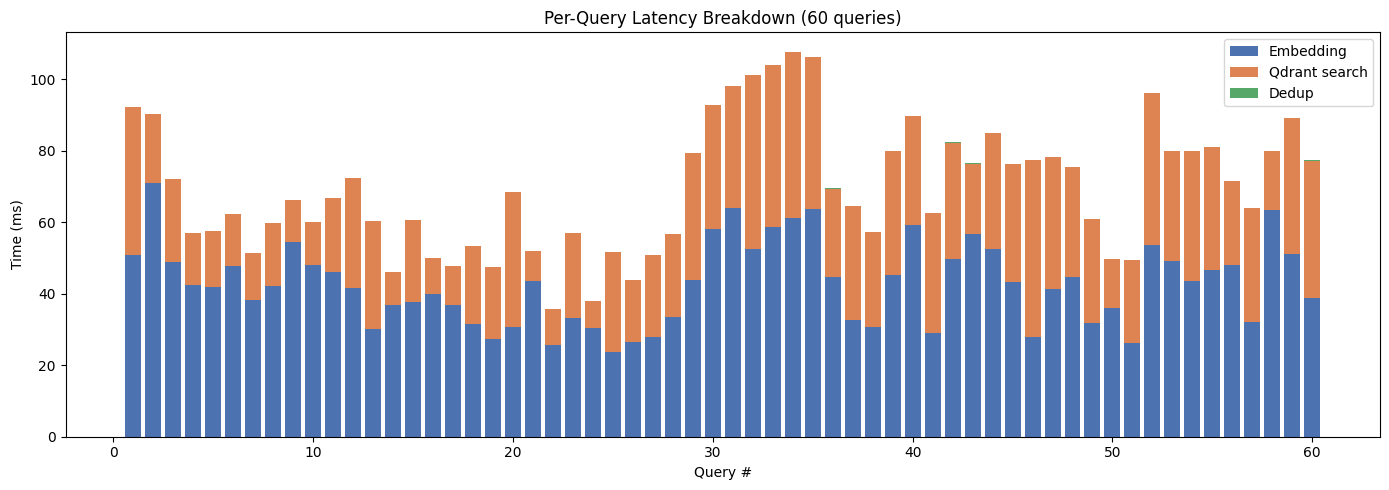

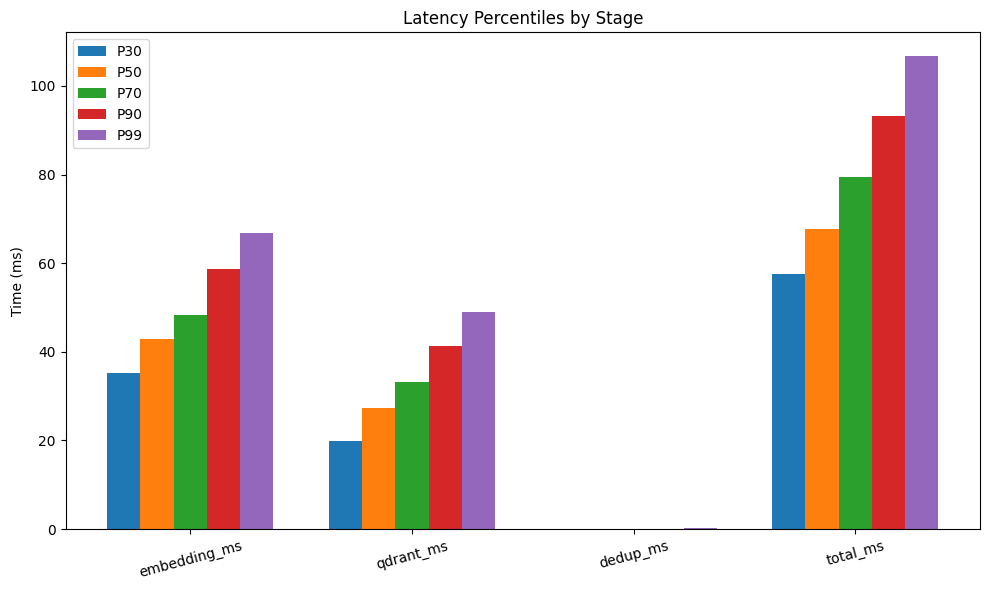

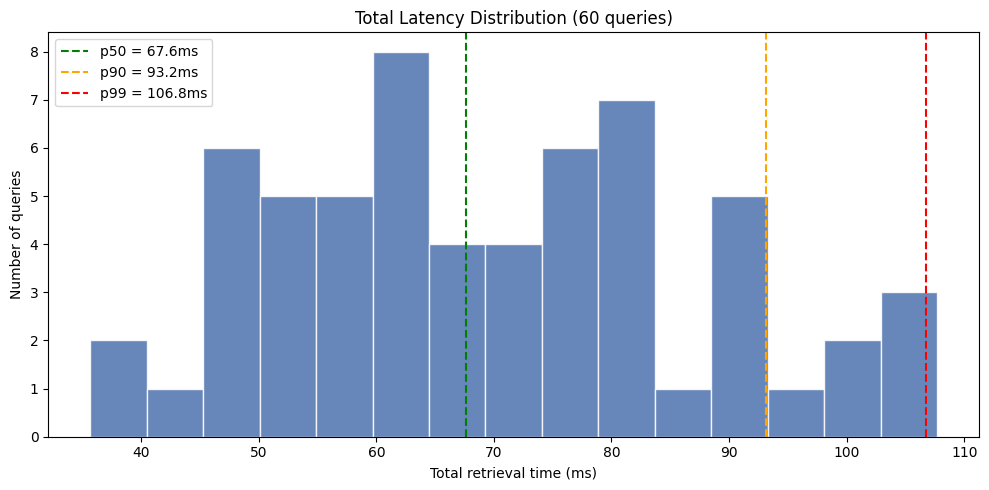

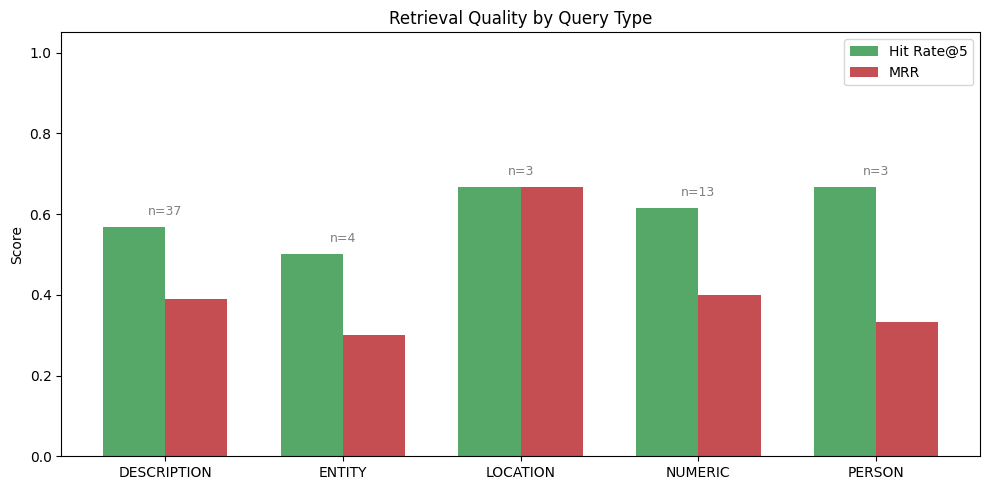

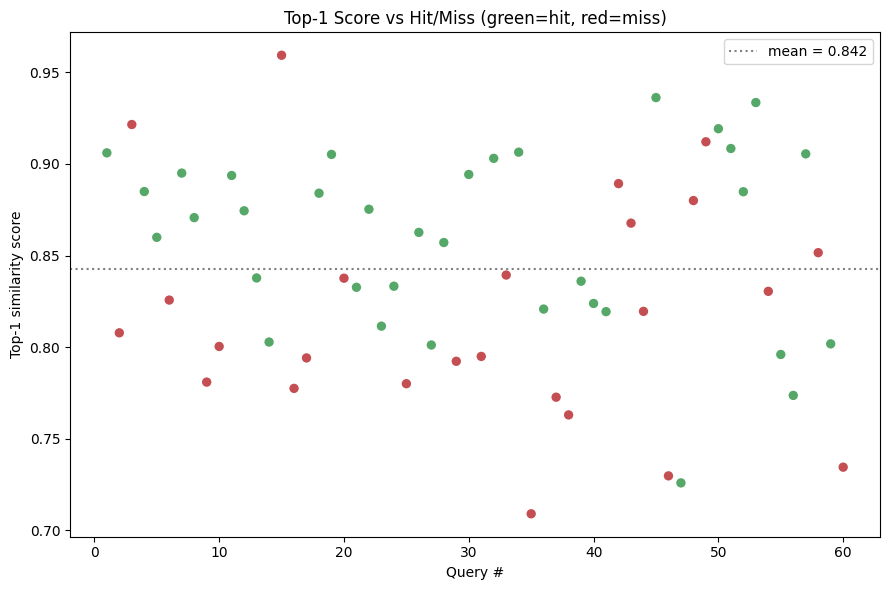

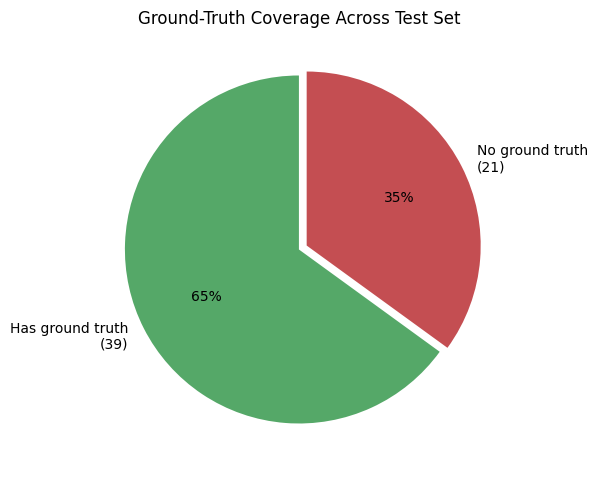

Saved 6 charts as PNGs in the working directory.


In [55]:
# %% CELL 24 — Visualize benchmark results with matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Load saved benchmark CSVs
# ---------------------------------------------------------
details_df = pd.read_csv("../update_version_2/benchmark_60q_details.csv")
timing_df = pd.read_csv("../update_version_2/benchmark_60q_timing_percentiles.csv")
quality_df = pd.read_csv("../update_version_2/benchmark_60q_quality.csv")
by_type_df = pd.read_csv("../update_version_2/benchmark_60q_by_query_type.csv")

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

# ---------------------------------------------------------
# 1. Latency breakdown per query (stacked bar: embed + qdrant + dedup)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))
x = details_df["query_idx"]
ax.bar(x, details_df["embedding_ms"], label="Embedding", color="#4C72B0")
ax.bar(x, details_df["qdrant_ms"], bottom=details_df["embedding_ms"], label="Qdrant search", color="#DD8452")
ax.bar(x, details_df["dedup_ms"],
       bottom=details_df["embedding_ms"] + details_df["qdrant_ms"],
       label="Dedup", color="#55A868")
ax.set_xlabel("Query #")
ax.set_ylabel("Time (ms)")
ax.set_title("Per-Query Latency Breakdown (60 queries)")
ax.legend()
plt.tight_layout()
plt.savefig("chart_latency_breakdown.png", dpi=150)
plt.show()

# ---------------------------------------------------------
# 2. Percentile comparison across stages (grouped bar)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
stages = timing_df["stage"]
percentiles = ["p30", "p50", "p70", "p90", "p99"]
x = np.arange(len(stages))
width = 0.15

for i, p in enumerate(percentiles):
    ax.bar(x + i * width, timing_df[p], width, label=p.upper())

ax.set_xticks(x + width * 2)
ax.set_xticklabels(stages, rotation=15)
ax.set_ylabel("Time (ms)")
ax.set_title("Latency Percentiles by Stage")
ax.legend()
plt.tight_layout()
plt.savefig("chart_percentiles_by_stage.png", dpi=150)
plt.show()

# ---------------------------------------------------------
# 3. Total latency distribution (histogram with percentile lines)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(details_df["total_ms"], bins=15, color="#4C72B0", edgecolor="white", alpha=0.85)

p50 = timing_df.loc[timing_df["stage"] == "total_ms", "p50"].values[0]
p90 = timing_df.loc[timing_df["stage"] == "total_ms", "p90"].values[0]
p99 = timing_df.loc[timing_df["stage"] == "total_ms", "p99"].values[0]

ax.axvline(p50, color="green", linestyle="--", label=f"p50 = {p50:.1f}ms")
ax.axvline(p90, color="orange", linestyle="--", label=f"p90 = {p90:.1f}ms")
ax.axvline(p99, color="red", linestyle="--", label=f"p99 = {p99:.1f}ms")
ax.set_xlabel("Total retrieval time (ms)")
ax.set_ylabel("Number of queries")
ax.set_title("Total Latency Distribution (60 queries)")
ax.legend()
plt.tight_layout()
plt.savefig("chart_latency_histogram.png", dpi=150)
plt.show()

# ---------------------------------------------------------
# 4. Hit rate & MRR by query type
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(by_type_df))
width = 0.35

ax.bar(x - width/2, by_type_df["hit_rate"], width, label="Hit Rate@5", color="#55A868")
ax.bar(x + width/2, by_type_df["mrr"], width, label="MRR", color="#C44E52")

ax.set_xticks(x)
ax.set_xticklabels(by_type_df["query_type"])
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Retrieval Quality by Query Type")
ax.legend()

# annotate bar values + sample size
for i, row in by_type_df.iterrows():
    ax.text(i, max(row["hit_rate"], row["mrr"]) + 0.03, f"n={int(row['n'])}",
            ha="center", fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("chart_quality_by_type.png", dpi=150)
plt.show()

# ---------------------------------------------------------
# 5. Top-1 similarity score vs hit/miss (scatter)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))
colors = details_df["hit@k"].map({True: "#55A868", False: "#C44E52"})
ax.scatter(details_df["query_idx"], details_df["top1_score"], c=colors, s=60, edgecolor="white")
ax.set_xlabel("Query #")
ax.set_ylabel("Top-1 similarity score")
ax.set_title("Top-1 Score vs Hit/Miss (green=hit, red=miss)")
ax.axhline(details_df["top1_score"].mean(), color="gray", linestyle=":",
           label=f"mean = {details_df['top1_score'].mean():.3f}")
ax.legend()
plt.tight_layout()
plt.savefig("chart_score_vs_hit.png", dpi=150)
plt.show()

# ---------------------------------------------------------
# 6. Ground-truth coverage (valid vs missing) — pie
# ---------------------------------------------------------
n_valid = int(quality_df["n_with_valid_gt"].values[0])
n_total = int(quality_df["n_queries"].values[0])
n_missing = n_total - n_valid

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [n_valid, n_missing],
    labels=[f"Has ground truth\n({n_valid})", f"No ground truth\n({n_missing})"],
    colors=["#55A868", "#C44E52"],
    autopct="%1.0f%%",
    startangle=90,
    explode=(0, 0.05),
)
ax.set_title("Ground-Truth Coverage Across Test Set")
plt.tight_layout()
plt.savefig("chart_gt_coverage.png", dpi=150)
plt.show()

print("Saved 6 charts as PNGs in the working directory.")